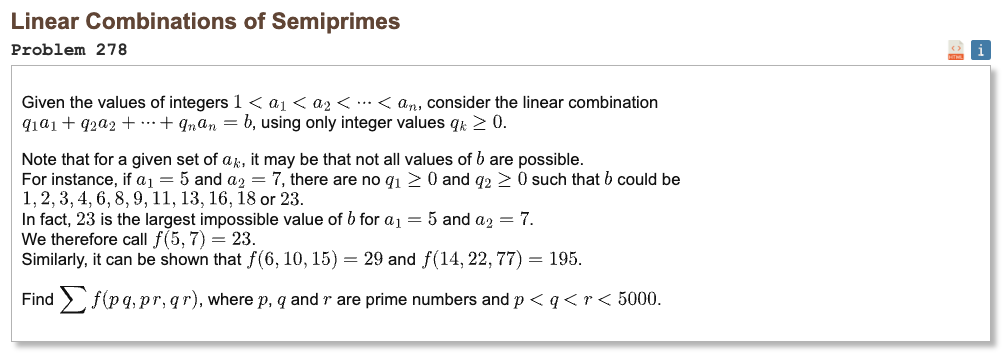

## Initial approach

* each valid case is built from three numbers formed by multiplying the primes in pairs
* for this specific structure, the largest impossible value follows a very neat direct pattern
* that means we do not need to solve a separate hard coin problem for every prime triple
* the task becomes adding the same kind of expression across all prime triples below 5000
* doing that one triple at a time would be too slow, so it is better to summarize the whole prime list with a few total values
* those totals let us capture all triple products and all pair products indirectly, without visiting every combination one by one
* once those summary values are computed, the final answer comes from one compact calculation

In [1]:
%%time
def sieve(limit):
    is_prime = [True] * limit
    is_prime[0] = False
    is_prime[1] = False

    p = 2
    while p * p < limit:
        if is_prime[p]:
            multiple = p * p
            while multiple < limit:
                is_prime[multiple] = False
                multiple += p
        p += 1

    return [i for i in range(2, limit) if is_prime[i]]

primes = sieve(5000)

n = len(primes)
s1 = sum(primes)
s2 = sum(p * p for p in primes)
s3 = sum(p * p * p for p in primes)

sum_pqr = (s1 * s1 * s1 - 3 * s1 * s2 + 2 * s3) // 6
sum_pair_products = (s1 * s1 - s2) // 2

result = 2 * sum_pqr - (n - 2) * sum_pair_products

print("Result:", result)

Result: 1228215747273908452
CPU times: user 1.13 ms, sys: 82 μs, total: 1.21 ms
Wall time: 1.19 ms
